# Idealized TCSPC decay simulation

This notebook demonstrates the first simplified TCSPC simulation workflow.

The procedure is:

1. Define a time axis.
2. Calculate the expected mono-exponential decay.
3. Sample measured photon counts using Poisson statistics.
4. Compare the expected and measured curves.
5. Save the generated data to a CSV file.

At this stage, the simulation does not yet include an instrument
response function (IRF).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tcspc_toolkit.simulation import simulate_ideal_decay

In [2]:
lifetime_true_ns = 2.5
amplitude_counts = 10_000.0
background_counts = 5.0
random_seed = 42

In [3]:
start_time_ns = 0.0
stop_time_ns = 20.0
number_of_bins = 512

time_ns = np.linspace(
    start=start_time_ns,
    stop=stop_time_ns,
    num=number_of_bins,
)

In [4]:
expected_counts, measured_counts = simulate_ideal_decay(
    time=time_ns,
    amplitude=amplitude_counts,
    lifetime=lifetime_true_ns,
    background=background_counts,
    random_seed=random_seed,
)

In [5]:
print("Time shape:", time_ns.shape)
print("Expected-count shape:", expected_counts.shape)
print("Measured-count shape:", measured_counts.shape)

Time shape: (512,)
Expected-count shape: (512,)
Measured-count shape: (512,)


In [6]:
for index in range(5):
    print(
        f"Bin {index}: "
        f"time = {time_ns[index]:.3f} ns, "
        f"expected = {expected_counts[index]:.2f}, "
        f"measured = {measured_counts[index]}"
    )

Bin 0: time = 0.000 ns, expected = 10005.00, measured = 10090
Bin 1: time = 0.039 ns, expected = 9849.66, measured = 9971
Bin 2: time = 0.078 ns, expected = 9696.74, measured = 9542
Bin 3: time = 0.117 ns, expected = 9546.19, measured = 9624
Bin 4: time = 0.157 ns, expected = 9397.98, measured = 9271


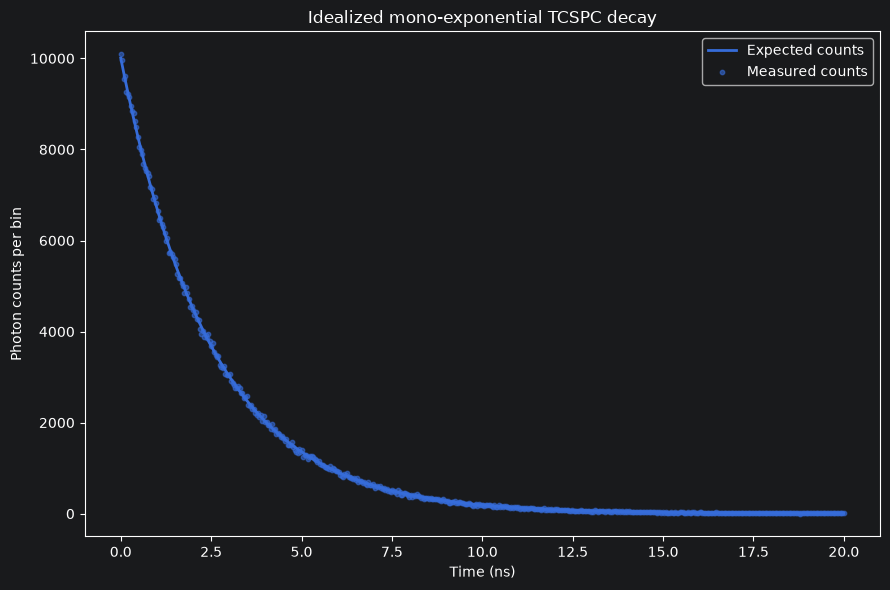

In [7]:
plt.figure(figsize=(9, 6))

plt.plot(
    time_ns,
    expected_counts,
    label="Expected counts",
    linewidth=2,
)

plt.scatter(
    time_ns,
    measured_counts,
    label="Measured counts",
    s=10,
    alpha=0.6,
)

plt.xlabel("Time (ns)")
plt.ylabel("Photon counts per bin")
plt.title("Idealized mono-exponential TCSPC decay")
plt.legend()
plt.tight_layout()
plt.show()

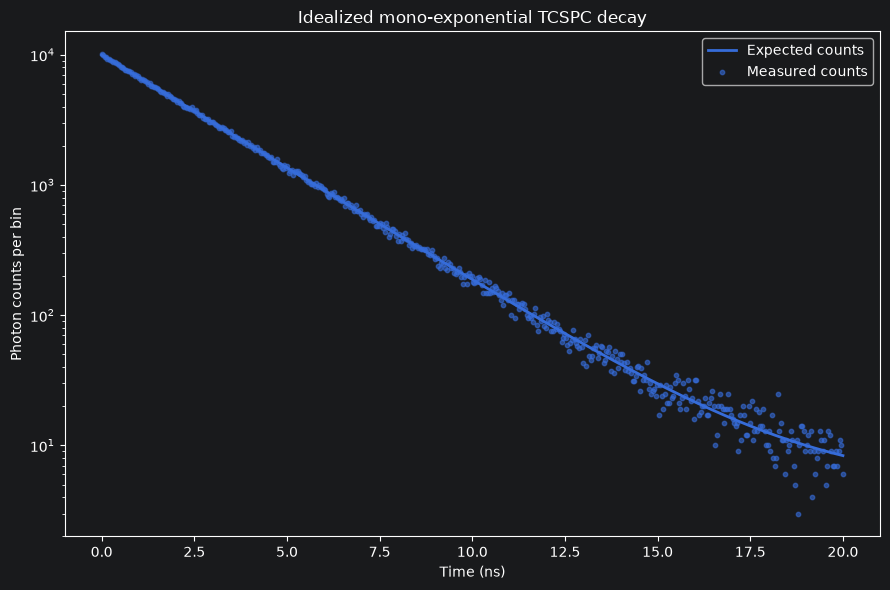

In [8]:
plt.figure(figsize=(9, 6))

plt.plot(
    time_ns,
    expected_counts,
    label="Expected counts",
    linewidth=2,
)

plt.scatter(
    time_ns,
    measured_counts,
    label="Measured counts",
    s=10,
    alpha=0.6,
)

plt.yscale("log")
plt.xlabel("Time (ns)")
plt.ylabel("Photon counts per bin")
plt.title("Idealized mono-exponential TCSPC decay")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
decay_data = pd.DataFrame(
    {
        "time_ns": time_ns,
        "expected_counts": expected_counts,
        "measured_counts": measured_counts,
        "lifetime_true_ns": lifetime_true_ns,
    }
)

In [10]:
print("Shape:", decay_data.shape)
print()

decay_data.info()

Shape: (512, 4)

<class 'pandas.DataFrame'>
RangeIndex: 512 entries, 0 to 511
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   time_ns           512 non-null    float64
 1   expected_counts   512 non-null    float64
 2   measured_counts   512 non-null    int64  
 3   lifetime_true_ns  512 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 16.1 KB


In [11]:
project_root = Path.cwd().parent
output_directory = project_root / "data" / "generated"

output_directory.mkdir(
    parents=True,
    exist_ok=True,
)

In [12]:
output_file = output_directory / "ideal_tcspc_decay.csv"

decay_data.to_csv(
    output_file,
    index=False,
)

print(f"Data saved to: {output_file}")

Data saved to: C:\Users\Yevhenii\PycharmProjects\scientific-python-transition\data\generated\ideal_tcspc_decay.csv


In [13]:
loaded_data = pd.read_csv(output_file)

loaded_data.head()

,time_ns,expected_counts,measured_counts,lifetime_true_ns
0,0.000000,10005.000000,10090,2.5
1,0.039139,9849.663342,9971,2.5
2,0.078278,9696.739632,9542,2.5
3,0.117417,9546.191388,9624,2.5
4,0.156556,9397.981710,9271,2.5


## Interpretation

The expected curve represents the mean number of photon counts predicted
for every time bin. The measured curve is one random realization sampled
from the corresponding Poisson distributions.

The relative fluctuations become stronger in the low-count tail because
the relative Poisson uncertainty is proportional to $\frac{1}{\sqrt{\lambda}}$.

## Current limitations

This first model is intentionally simplified. It does not yet include:

- an instrument response function;
- convolution or reconvolution;
- temporal shifts;
- detector effects;
- pile-up;
- multi-exponential decays;
- a time-dependent background.

These effects will be introduced in later versions of the toolkit.